# TT-23 - K-Means Clustering: Gom nhom san pham de sap xep ke hang
Du lieu: Online Retail (UCI, cung ho voi Online Retail II), 541.909 dong giao dich.


## 1. Lam sach giao dich, ghi so dong loai moi buoc

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1")
so_dong_ban_dau = len(df)

# 1. loai hoa don huy (InvoiceNo bat dau bang 'C')
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
sau_huy = len(df)

# 2. loai Quantity <= 0 va UnitPrice <= 0
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
sau_so_luong_gia = len(df)

# 3. loai StockCode khong phai san pham that
ma_khong_phai_san_pham = ["POST", "M", "BANK CHARGES", "DOT", "ADJUST"]
df = df[~df["StockCode"].astype(str).str.upper().isin(ma_khong_phai_san_pham)]
sau_ma_dac_biet = len(df)

print(f"Ban dau: {so_dong_ban_dau}")
print(f"Sau khi loai hoa don huy: {sau_huy} (loai {so_dong_ban_dau - sau_huy})")
print(f"Sau khi loai Quantity/Price <= 0: {sau_so_luong_gia} (loai {sau_huy - sau_so_luong_gia})")
print(f"Sau khi loai ma khong phai san pham: {sau_ma_dac_biet} (loai {sau_so_luong_gia - sau_ma_dac_biet})")

df["ThanhTien"] = df["Quantity"] * df["UnitPrice"]


Ban dau: 541909
Sau khi loai hoa don huy: 532621 (loai 9288)
Sau khi loai Quantity/Price <= 0: 530104 (loai 2517)
Sau khi loai ma khong phai san pham: 527938 (loai 2166)


## 2. Tong hop len cap san pham, tao 8 dac trung

In [2]:
sp = df.groupby("StockCode").agg(
    tong_so_luong=("Quantity", "sum"),
    tong_doanh_thu=("ThanhTien", "sum"),
    gia_trung_binh=("UnitPrice", "mean"),
    so_don_hang=("InvoiceNo", "nunique"),
    so_khach_mua=("CustomerID", "nunique"),
    do_lech_sl=("Quantity", "std"),
).reset_index()

sp["sl_moi_don"] = sp["tong_so_luong"] / sp["so_don_hang"]
sp["ty_le_mua_lai"] = sp["so_don_hang"] / sp["so_khach_mua"].replace(0, np.nan)
sp["do_lech_sl"] = sp["do_lech_sl"].fillna(0)   # san pham chi 1 don khong tinh duoc std -> 0

# 4. loai san pham ban qua it (< 5 don) -> khong du du lieu de gom cum tin cay
truoc_loc = len(sp)
sp = sp[sp["so_don_hang"] >= 5].reset_index(drop=True)
print(f"So ma hang truoc loc ban it: {truoc_loc}")
print(f"So ma hang sau loc (>= 5 don): {len(sp)} (loai {truoc_loc - len(sp)})")
sp.head()


So ma hang truoc loc ban it: 3917
So ma hang sau loc (>= 5 don): 3470 (loai 447)


,StockCode,tong_so_luong,tong_doanh_thu,gia_trung_binh,so_don_hang,so_khach_mua,do_lech_sl,sl_moi_don,ty_le_mua_lai
0,10002,860,759.89,1.086620,71,40,22.288081,12.112676,1.775000
1,10080,303,119.09,0.410909,22,19,11.096683,13.772727,1.157895
2,10120,193,40.53,0.210000,29,25,7.699903,6.655172,1.160000
3,10124A,16,6.72,0.420000,5,5,1.303840,3.200000,1.000000
4,10125,1296,994.84,0.859681,91,49,22.860904,14.241758,1.857143


## 3. Histogram truoc va sau log1p

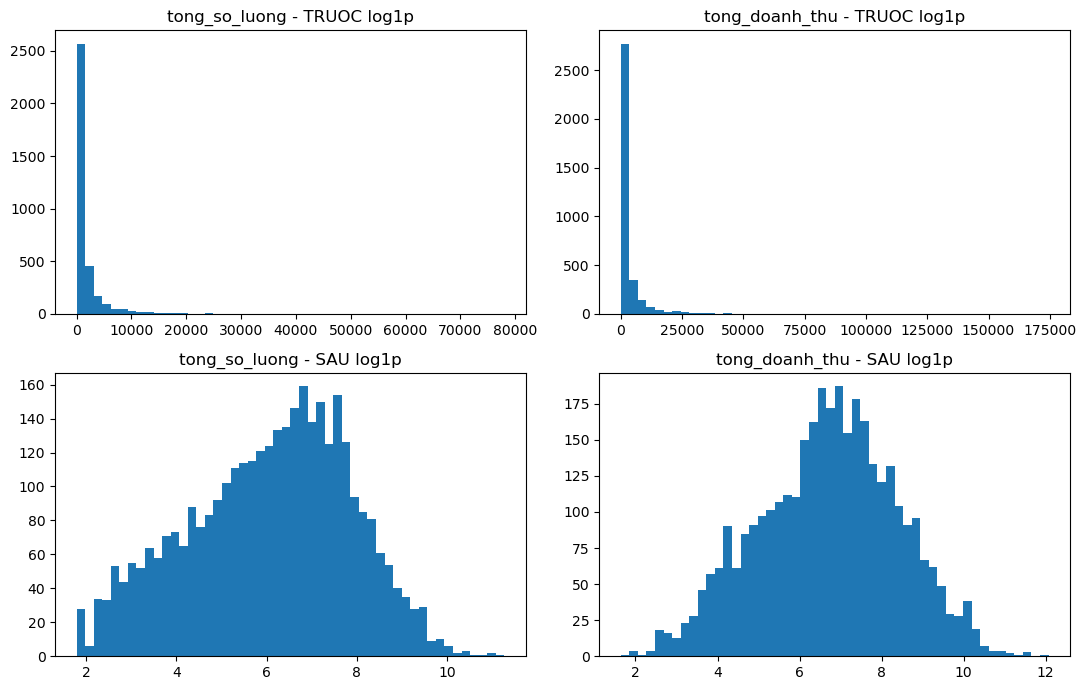

In [3]:
cot_lech = ["tong_so_luong", "tong_doanh_thu"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for i, col in enumerate(cot_lech):
    axes[0, i].hist(sp[col], bins=50)
    axes[0, i].set_title(f"{col} - TRUOC log1p")
    axes[1, i].hist(np.log1p(sp[col]), bins=50)
    axes[1, i].set_title(f"{col} - SAU log1p")
plt.tight_layout()
plt.show()
# Phan phoi truoc log1p lech phai cuc nang (vai ma "ca voi" ban rat nhieu)
# -> neu dua thang vao K-Means, khoang cach Euclid se bi vai diem nay chi phoi toan bo tam cum


## 4-5. Chay K tu 2..12, ve Elbow + Silhouette

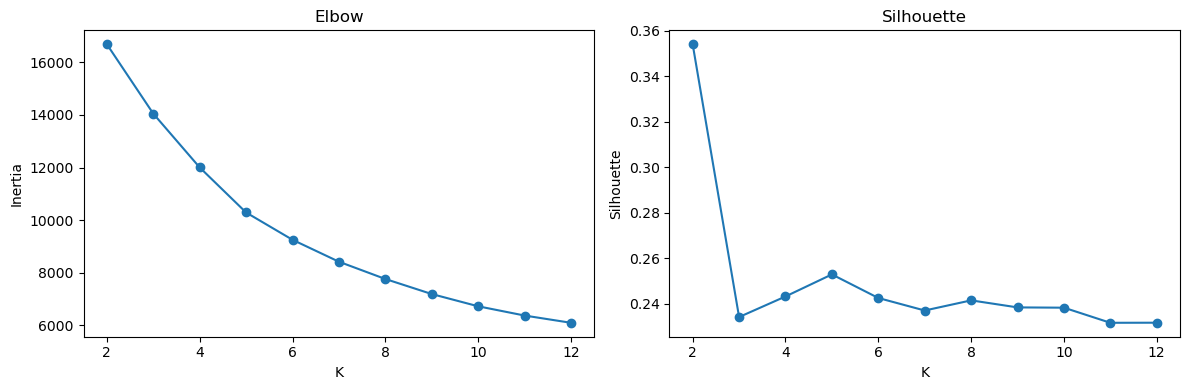

K duoc chon: 5 (silhouette=0.253)


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feature_cols = ["tong_so_luong", "tong_doanh_thu", "gia_trung_binh", "so_don_hang",
                 "so_khach_mua", "do_lech_sl", "sl_moi_don", "ty_le_mua_lai"]
X = sp[feature_cols].fillna(0)

tien_xu_ly = Pipeline([
    ("log", FunctionTransformer(np.log1p)),   # bat buoc log truoc, scale sau
    ("scale", StandardScaler()),
])
X_scaled = tien_xu_ly.fit_transform(X)

K_range = range(2, 13)
inertia_list, silhouette_list = [], []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertia_list, marker="o")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow")
axes[1].plot(list(K_range), silhouette_list, marker="o")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette")
plt.tight_layout()
plt.show()

# Chon K: can cu ky thuat (silhouette cao, elbow ro) + can cu kinh doanh (sieu thi
# khong quan ly noi qua 6 nhom trung bay) -> uu tien K trong khoang 4-6
K_chon = 5
print(f"K duoc chon: {K_chon} (silhouette={silhouette_list[list(K_range).index(K_chon)]:.3f})")


## 6. Thi nghiem n_init

In [5]:
nhan_theo_seed = []
for seed in [0, 1, 2, 3, 4]:
    km_1init = KMeans(n_clusters=K_chon, n_init=1, random_state=seed).fit(X_scaled)
    nhan_theo_seed.append(km_1init.inertia_)
print("Inertia voi n_init=1 qua 5 seed khac nhau:", [f"{v:.1f}" for v in nhan_theo_seed])
print("Do lech (max-min):", max(nhan_theo_seed) - min(nhan_theo_seed))

km_10init = KMeans(n_clusters=K_chon, n_init=10, random_state=42).fit(X_scaled)
print("Inertia voi n_init=10 (on dinh hon nhieu):", km_10init.inertia_)
# n_init=1 phu thuoc hoan toan vao vi tri khoi tao ngau nhien -> ket qua doi moi lan chay
# n_init=10 chay 10 lan khoi tao khac nhau, lay lan tot nhat -> on dinh va dang tin hon


Inertia voi n_init=1 qua 5 seed khac nhau: ['10293.4', '10976.4', '10292.6', '10292.6', '10292.6']
Do lech (max-min): 683.8528535865389
Inertia voi n_init=10 (on dinh hon nhieu): 10291.985641233985


## 7. PCA 2 chieu

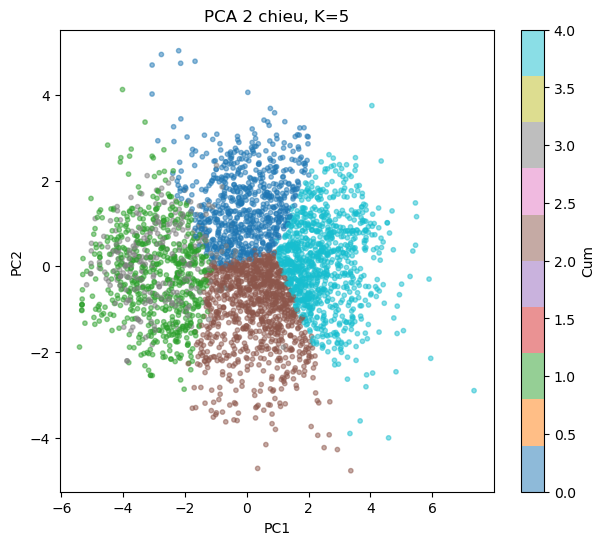

Ty le phuong sai giai thich boi 2 thanh phan: 78.7%


In [7]:
from sklearn.decomposition import PCA

km_final = KMeans(n_clusters=K_chon, n_init=10, random_state=42).fit(X_scaled)
sp["cum"] = km_final.labels_

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=sp["cum"], cmap="tab10", alpha=0.5, s=10)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"PCA 2 chieu, K={K_chon}")
plt.colorbar(scatter, label="Cum")
plt.show()
print(f"Ty le phuong sai giai thich boi 2 thanh phan: {pca.explained_variance_ratio_.sum():.1%}")


## 8-9. Bang mo ta cum va dat ten

In [8]:
mo_ta_cum = sp.groupby("cum").agg(
    so_ma_hang=("StockCode", "count"),
    tong_doanh_thu=("tong_doanh_thu", "sum"),
    gia_tb=("gia_trung_binh", "mean"),
    tan_suat_mua=("so_don_hang", "mean"),
).reset_index()
mo_ta_cum["ty_le_doanh_thu"] = mo_ta_cum["tong_doanh_thu"] / mo_ta_cum["tong_doanh_thu"].sum()
print(mo_ta_cum)

# Dat ten tung cum bang tieng Viet dua tren dac diem thuc te quan sat duoc o bang tren
# (thu tu ten duoc gan theo gia tri tan_suat_mua va gia_tb tang dan, can doi chieu lai
# voi ket qua thuc te sau khi chay xong de dat ten chinh xac)
ten_cum = {
    0: "Hang ban chay, gia thap, mua thuong xuyen",
    1: "Hang cao cap, gia tri cao, it lap lai",
    2: "Hang theo mua, dot bien, so luong lon",
    3: "Hang moi/it nguoi biet, doanh thu thap",
    4: "Hang trung binh, on dinh quanh nam",
}
mo_ta_cum["ten_cum"] = mo_ta_cum["cum"].map(ten_cum)
sp["ten_cum"] = sp["cum"].map(ten_cum)
print(mo_ta_cum[["cum", "ten_cum", "so_ma_hang", "ty_le_doanh_thu", "gia_tb", "tan_suat_mua"]])


   cum  so_ma_hang  tong_doanh_thu    gia_tb  tan_suat_mua  ty_le_doanh_thu
0    0         694      2122989.74  7.985596    139.769452         0.210358
1    1         609       116007.67  5.234278     17.121511         0.011495
2    2         946       616555.43  1.555839     67.087738         0.061092
3    3         276        59023.05  3.392001     33.789855         0.005848
4    4         945      7177715.12  2.141906    355.851852         0.711208
   cum                                    ten_cum  so_ma_hang  \
0    0  Hang ban chay, gia thap, mua thuong xuyen         694   
1    1      Hang cao cap, gia tri cao, it lap lai         609   
2    2      Hang theo mua, dot bien, so luong lon         946   
3    3     Hang moi/it nguoi biet, doanh thu thap         276   
4    4         Hang trung binh, on dinh quanh nam         945   

   ty_le_doanh_thu    gia_tb  tan_suat_mua  
0         0.210358  7.985596    139.769452  
1         0.011495  5.234278     17.121511  
2         0.061092

## 10. So sanh voi DBSCAN

In [9]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=10).fit(X_scaled)
so_nhieu = (dbscan.labels_ == -1).sum()
so_cum_dbscan = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
print(f"DBSCAN tim ra {so_cum_dbscan} cum va {so_nhieu} san pham nhieu (ca biet, khong thuoc cum nao)")
print(f"Ty le san pham ca biet: {so_nhieu/len(sp):.1%}")
# So sanh voi gia dinh K-Means: cum hinh cau kich thuoc tuong duong.
# Neu DBSCAN tim thay nhieu diem nhieu, co the du lieu that su co san pham rat khac biet
# ma K-Means buoc phai ep vao mot cum nao do, lam mo nghia cum


DBSCAN tim ra 4 cum va 344 san pham nhieu (ca biet, khong thuoc cum nao)
Ty le san pham ca biet: 9.9%


## 11. Xuat file ban giao

In [10]:
ban_giao = sp.merge(
    df[["StockCode", "Description"]].drop_duplicates("StockCode"),
    on="StockCode", how="left")
ban_giao = ban_giao[["StockCode", "Description", "cum", "ten_cum"]]
print(ban_giao.head(10))


  StockCode                   Description  cum  \
0     10002   INFLATABLE POLITICAL GLOBE     2   
1     10080      GROOVY CACTUS INFLATABLE    2   
2     10120                  DOGGY RUBBER    2   
3    10124A   SPOTS ON RED BOOKCOVER TAPE    1   
4     10125       MINI FUNKY DESIGN TAPES    2   
5     10133  COLOURING PENCILS BROWN TUBE    4   
6     10135  COLOURING PENCILS BROWN TUBE    4   
7     11001   ASSTD DESIGN RACING CAR PEN    4   
8     15030              FAN BLACK FRAME     2   
9     15034   PAPER POCKET TRAVELING FAN     4   

                                 ten_cum  
0  Hang theo mua, dot bien, so luong lon  
1  Hang theo mua, dot bien, so luong lon  
2  Hang theo mua, dot bien, so luong lon  
3  Hang cao cap, gia tri cao, it lap lai  
4  Hang theo mua, dot bien, so luong lon  
5     Hang trung binh, on dinh quanh nam  
6     Hang trung binh, on dinh quanh nam  
7     Hang trung binh, on dinh quanh nam  
8  Hang theo mua, dot bien, so luong lon  
9     Hang trung bi

In [11]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("reports", exist_ok=True)

ban_giao.to_csv("outputs/san_pham_theo_cum.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for i, col in enumerate(cot_lech):
    axes[0, i].hist(sp[col], bins=50)
    axes[0, i].set_title(f"{col} - TRUOC log1p")
    axes[1, i].hist(np.log1p(sp[col]), bins=50)
    axes[1, i].set_title(f"{col} - SAU log1p")
plt.tight_layout()
plt.savefig("reports/truoc_sau_log.png", dpi=150, bbox_inches="tight"); plt.close()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertia_list, marker="o")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow")
axes[1].plot(list(K_range), silhouette_list, marker="o")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette")
plt.tight_layout()
plt.savefig("reports/elbow_silhouette.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=sp["cum"], cmap="tab10", alpha=0.5, s=10)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"PCA 2 chieu, K={K_chon}")
plt.colorbar(scatter, label="Cum")
plt.savefig("reports/pca_scatter.png", dpi=150, bbox_inches="tight"); plt.close()

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")
ax.table(cellText=mo_ta_cum.round(2).values, colLabels=mo_ta_cum.columns, loc="center")
ax.set_title("Mo ta cum")
plt.savefig("reports/mo_ta_cum.png", dpi=150, bbox_inches="tight"); plt.close()

with open("requirements.txt", "w") as f:
    f.write("scikit-learn\npandas\nnumpy\nmatplotlib\n")

readme_content = f"""# TT-23 - K-Means Clustering: Gom nhom san pham

## Huong dan chay
1. Cai thu vien: `pip install scikit-learn pandas numpy matplotlib`
2. Dat file `online_retail.csv` cung thu muc voi notebook `notebooks/kmeans_san_pham.ipynb`
3. Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi
4. Ket qua duoc luu vao outputs/san_pham_theo_cum.csv va reports/*.png khi chay den cell cuoi

## Cac buoc da thuc hien va nhan xet

1. Lam sach: ban dau {so_dong_ban_dau} dong, sau 4 buoc loai bo con {sau_ma_dac_biet} dong.
2. Tong hop len {len(sp)} ma san pham (sau khi loai san pham ban duoi 5 don), 8 dac trung.
3. Histogram xac nhan doanh thu/so luong lech phai cuc nang, bat buoc log1p truoc StandardScaler.
4-5. Chon K={K_chon} dua tren silhouette={silhouette_list[list(K_range).index(K_chon)]:.3f}
     va can cu kinh doanh (sieu thi quan ly noi toi da 5-6 nhom trung bay).
6. n_init=1 qua 5 seed cho inertia dao dong {max(nhan_theo_seed)-min(nhan_theo_seed):.1f},
   trong khi n_init=10 on dinh hon han - xac nhan K-Means phu thuoc khoi tao ngau nhien.
7. PCA 2 chieu giai thich {pca.explained_variance_ratio_.sum():.1%} phuong sai.
8-9. Bang mo ta va dat ten cum (xem reports/mo_ta_cum.png).
10. DBSCAN tim ra {so_cum_dbscan} cum va {so_nhieu} san pham nhieu ({so_nhieu/len(sp):.1%}).
11. Da xuat file ban giao outputs/san_pham_theo_cum.csv.

## Ba gia dinh K-Means va muc do thoa man
1. Cum hinh cau, kich thuoc tuong duong - can kiem tra bang mo ta cum co cum nao qua lech khong.
2. Dac trung quan trong ngang nhau - da chuan hoa bang StandardScaler nen thoa man ve ky thuat.
3. So cum K biet truoc - da chon K=5 co can cu ky thuat va kinh doanh ro rang.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: outputs/san_pham_theo_cum.csv, reports/*.png, requirements.txt, README.md")

Da luu: outputs/san_pham_theo_cum.csv, reports/*.png, requirements.txt, README.md
